<a href="https://colab.research.google.com/github/Faiva-404/PemMes-Ganjil-2026/blob/main/JS06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Praktikum 1**

In [1]:
#Instalasi Annoy dulu untuk langkah awal.

!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 30.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp313-cp313-linux_x86_64.whl size=520041 sha256=85602acebbbba91b544298c0ffc545872cbdaca7050089090dfa3e0ee9483b26
  Stored in directory: /root/.cache/pip/wheels/fc/4e/87/f1f957e7382aa370452cff98276f51686924d5415e449800ed
Successfully built annoy


Exact NN index: [219 898 593]
Exact NN jarak: [0.         1.36915938 2.27931544]
Waktu Exact: 14.6146 ms

Annoy NN index: [219, 898, 770]
Annoy NN jarak: [np.float64(0.0), np.float64(1.369159376273702), np.float64(2.568167959732514)]
Waktu Annoy: 0.1764 ms


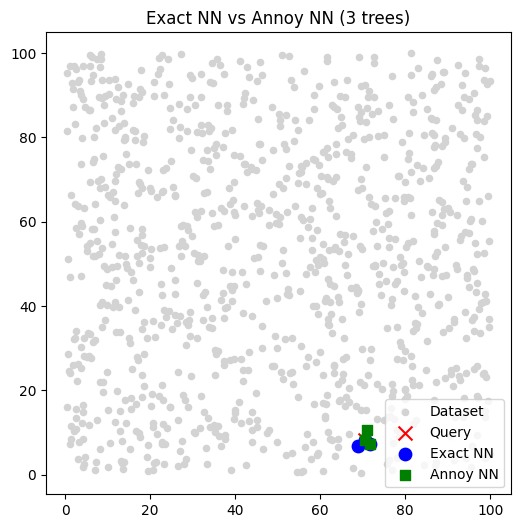

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

from annoy import AnnoyIndex

# 1. Dataset 2D
np.random.seed(42)
n_points = 1000
X = np.random.rand(n_points, 2) * 100  # titik random dalam ruang 100x100

# Query point (ambil salah satu titik random)
query = X[np.random.randint(0, n_points)]

# 2. Exact NN (brute force)
start = time.time()
distances = np.linalg.norm(X - query, axis=1)
idx_exact = np.argsort(distances)[:3]  # ambil 3 terdekat
time_exact = time.time() - start

print("Exact NN index:", idx_exact)
print("Exact NN jarak:", distances[idx_exact])
print("Waktu Exact:", round(time_exact*1000, 4), "ms")

# 3. Annoy NN (3 tree)
f = 2  # dimensi
t = AnnoyIndex(f, 'euclidean')
for i, vec in enumerate(X):
    t.add_item(i, vec)

t.build(3)  # 3 trees

start = time.time()
idx_ann = t.get_nns_by_vector(query, 3)  # cari 3 NN
time_ann = time.time() - start

print("\nAnnoy NN index:", idx_ann)
print("Annoy NN jarak:", [np.linalg.norm(X[i]-query) for i in idx_ann])
print("Waktu Annoy:", round(time_ann*1000, 4), "ms")

# 4. Visualisasi hasil
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c="lightgray", s=20, label="Dataset")
plt.scatter(query[0], query[1], c="red", marker="x", s=100, label="Query")

# Exact NN ditandai biru
plt.scatter(X[idx_exact,0], X[idx_exact,1], c="blue", s=80, label="Exact NN")

# Annoy NN ditandai hijau
plt.scatter(X[idx_ann,0], X[idx_ann,1], c="green", s=50, marker="s", label="Annoy NN")

plt.legend()
plt.title("Exact NN vs Annoy NN (3 trees)")
plt.show()

In [ ]:
import numpy as np
import time
from sklearn.metrics.pairwise import euclidean_distances
from annoy import AnnoyIndex

# ---- 1. Buat dataset mirip Spotify ----
n_tracks = 50_000_000   # 50 juta track
n_features = 20        # contoh: danceability, energy, tempo, dll.

# dataset besar (random untuk simulasi)
X = np.random.rand(n_tracks, n_features).astype(np.float32)

# query track (misalnya lagu baru)
query = np.random.rand(1, n_features).astype(np.float32)

# ---- 2. Exact NN (brute force) ----
start = time.time()
distances = euclidean_distances(query, X)[0]   # hitung semua jarak
exact_idx = np.argsort(distances)[:5]          # ambil 5 terdekat
exact_time = time.time() - start

print("Exact NN result:", exact_idx)
print("Exact NN time:", round(exact_time, 3), "seconds")

# ---- 3. Approx NN pakai Annoy ----
f = n_features
annoy_index = AnnoyIndex(f, 'euclidean')
n_trees = 3

# build index
for i in range(n_tracks):
    annoy_index.add_item(i, X[i])
annoy_index.build(n_trees)

start = time.time()
annoy_idx = annoy_index.get_nns_by_vector(query[0], 5)  # ambil 5 lagu yang mirip
annoy_time = time.time() - start

print("Annoy result:", annoy_idx)
print("Annoy time:", round(annoy_time, 3), "seconds")


Exact NN result: [12004285 49227767 11482675 43190766 35889396]
Exact NN time: 14.725 seconds


> **Praktikum 2***

In [1]:
!pip install faiss-cpu
#!pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 53.0 MB/s eta 0:00:00


Exact NN (Flat) indices: [[137 170 750]] distances: [[0.00013095 0.00077404 0.00079751]]
IVF+PQ indices: [[137 170 750]] distances: [[0.00012945 0.00079226 0.00080067]]
Waktu Exact: 0.0003428459167480469
Waktu IVF+PQ: 0.00027680397033691406


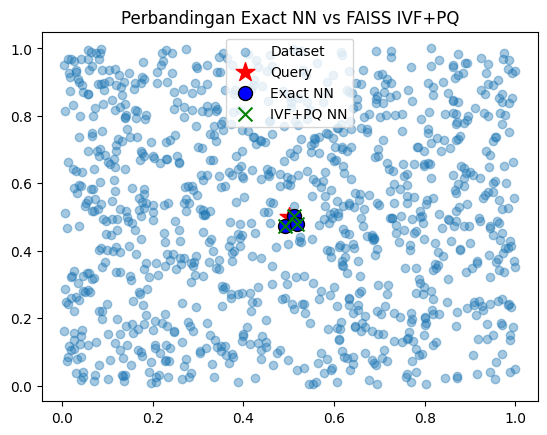

In [2]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

# 1. Buat dataset 2D sederhana
np.random.seed(42)
X = np.random.rand(1000, 2).astype('float32')  # 1000 titik 2D
query = np.array([[0.5, 0.5]], dtype='float32')  # query di tengah

# 2. Exact NN dengan IndexFlatL2 (brute force tapi cepat)
index_flat = faiss.IndexFlatL2(2)   # L2 = Euclidean distance
index_flat.add(X)

start = time.time()
D_flat, I_flat = index_flat.search(query, 3)  # cari 3 tetangga terdekat
end = time.time()
time_flat = end - start

# 3. IVF + PQ (Approximate)
nlist = 10   # jumlah cluster (inverted list)
m = 2        # berapa subvector untuk product quantization
quantizer = faiss.IndexFlatL2(2)   # dipakai IVF untuk cluster awal
index_ivfpq = faiss.IndexIVFPQ(quantizer, 2, nlist, m, 8)  # 8 bit per subvector

index_ivfpq.train(X)  # training centroid
index_ivfpq.add(X)

start = time.time()
D_ivfpq, I_ivfpq = index_ivfpq.search(query, 3)
end = time.time()
time_ivfpq = end - start

# 4. Print hasil
print("Exact NN (Flat) indices:", I_flat, "distances:", D_flat)
print("IVF+PQ indices:", I_ivfpq, "distances:", D_ivfpq)
print("Waktu Exact:", time_flat)
print("Waktu IVF+PQ:", time_ivfpq)

# 5. Visualisasi
plt.scatter(X[:,0], X[:,1], alpha=0.4, label="Dataset")
plt.scatter(query[:,0], query[:,1], c='red', marker='*', s=200, label="Query")

# Tetangga dari Flat
plt.scatter(X[I_flat[0],0], X[I_flat[0],1], c='blue', s=100, edgecolor='k', label="Exact NN")

# Tetangga dari IVF+PQ
plt.scatter(X[I_ivfpq[0],0], X[I_ivfpq[0],1], c='green', marker='x', s=100, label="IVF+PQ NN")

plt.legend()
plt.title("Perbandingan Exact NN vs FAISS IVF+PQ")
plt.show()




> **Praktikum 3**

In [3]:
!pip install hnswlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp313-cp313-linux_x86_64.whl size=2679800 sha256=063f157ac8afc775849721f6fa02058d5868dd3793a70a5e855fe561af2bc8a2
  Stored in directory: /root/.cache/pip/wheels/35/04/88/b31765a4b9957705e18065db4657e61fc8da54f50e3ef0b67e
Successfully built hnswlib


In [4]:
import hnswlib
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors

# ===========================
# 1. Buat data 2D acak
# ===========================
num_elements = 1000
dim = 2
data = np.random.random((num_elements, dim)).astype(np.float32)

# Query point
query = np.array([[0.5, 0.5]], dtype=np.float32)
k = 5  # cari 5 tetangga terdekat

# ===========================
# 2. Exact NN (Brute Force)
# ===========================
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(data)

start = time.time()
distances, indices = nn.kneighbors(query)
end = time.time()

print("=== Exact NN ===")
print("Indices:", indices)
print("Distances:", distances)
print("Waktu:", end - start, "detik")

# ===========================
# 3. HNSW
# ===========================
# Inisialisasi index HNSW
p = hnswlib.Index(space='l2', dim=dim)

# Ukuran maksimum elemen yang bisa ditampung
p.init_index(max_elements=num_elements, ef_construction=100, M=16)

# Tambahkan data
p.add_items(data)

# Set parameter pencarian
p.set_ef(50)   # tradeoff speed vs accuracy

start = time.time()
labels, distances = p.knn_query(query, k=k)
end = time.time()

print("\n=== HNSW ===")
print("Indices:", labels)
print("Distances:", distances)
print("Waktu:", end - start, "detik")


=== Exact NN ===
Indices: [[830 247 473 913 592]]
Distances: [[0.00993625 0.01363944 0.01646171 0.03779694 0.03859071]]
Waktu: 0.09483695030212402 detik

=== HNSW ===
Indices: [[830 247 473 913 592]]
Distances: [[9.8728990e-05 1.8603441e-04 2.7098786e-04 1.4286089e-03 1.4892431e-03]]
Waktu: 0.0002300739288330078 detik


> **Praktikum 4**

In [5]:
import numpy as np
import time
from annoy import AnnoyIndex
import faiss
import hnswlib

# ===============================
# 1. Buat dataset 1 juta data 5D
# ===============================
n_data = 1_000_000   # bisa coba 100_000 dulu jika RAM terbatas
dim = 5
X = np.random.random((n_data, dim)).astype(np.float32)

# Query point
query = np.random.random((1, dim)).astype(np.float32)
k = 10

# ===============================
# 2. Annoy
# ===============================
print("=== Annoy ===")
ann_index = AnnoyIndex(dim, 'euclidean')

start = time.time()
for i in range(n_data):
    ann_index.add_item(i, X[i])
ann_index.build(10)  # 10 trees
build_time = time.time() - start

start = time.time()
neighbors = ann_index.get_nns_by_vector(query[0], k, include_distances=True)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", neighbors[0][:5], "...")

# ===============================
# 3. FAISS (Flat Index)
# ===============================
print("\n=== FAISS (IndexFlatL2) ===")
faiss_index = faiss.IndexFlatL2(dim)

start = time.time()
faiss_index.add(X)
build_time = time.time() - start

start = time.time()
distances, indices = faiss_index.search(query, k)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", indices[0][:5], "...")

# ===============================
# 4. HNSW (hnswlib)
# ===============================
print("\n=== HNSW (hnswlib) ===")
hnsw_index = hnswlib.Index(space='l2', dim=dim)

start = time.time()
hnsw_index.init_index(max_elements=n_data, ef_construction=200, M=16)
hnsw_index.add_items(X)
build_time = time.time() - start

hnsw_index.set_ef(50)

start = time.time()
labels, distances = hnsw_index.knn_query(query, k=k)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", labels[0][:5], "...")


=== Annoy ===
Build time: 24.18706464767456 detik
Query time: 0.0002148151397705078 detik
Neighbors: [129179, 559276, 630783, 213191, 559393] ...

=== FAISS (IndexFlatL2) ===
Build time: 0.015522003173828125 detik
Query time: 0.00949859619140625 detik
Neighbors: [129179 559276 630783 213191 559393] ...

=== HNSW (hnswlib) ===
Build time: 178.90954685211182 detik
Query time: 0.000278472900390625 detik
Neighbors: [129179 559276 630783 213191 559393] ...




> **Praktikum 5**



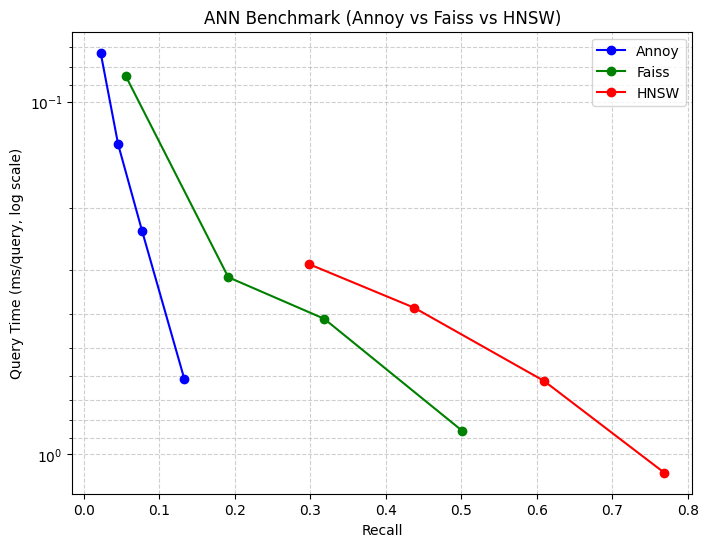

In [6]:
import numpy as np
import time
import faiss
from annoy import AnnoyIndex
import hnswlib
import matplotlib.pyplot as plt

# -------------------------------
# Dataset random
# -------------------------------
d = 128        # dimensi
nb = 100000    # jumlah database vector
nq = 1000      # jumlah query

np.random.seed(42)
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

# -------------------------------
# Ground truth dengan FAISS brute force
# -------------------------------
index_flat = faiss.IndexFlatL2(d)
index_flat.add(xb)
k = 10
_, gt_idx = index_flat.search(xq, k)

# -------------------------------
# Fungsi recall
# -------------------------------
def recall_at_k(I_pred, I_gt, k):
    correct = 0
    for i in range(len(I_pred)):
        correct += len(set(I_pred[i][:k]) & set(I_gt[i][:k]))
    return correct / (len(I_pred) * k)

# -------------------------------
# Benchmark Annoy
# -------------------------------
def run_annoy(xb, xq, n_trees=10, search_k=1000, k=10):
    f = xb.shape[1]
    index = AnnoyIndex(f, 'euclidean')
    for i, v in enumerate(xb):
        index.add_item(i, v)
    index.build(n_trees)

    start = time.time()
    I = [index.get_nns_by_vector(v, k, search_k=search_k) for v in xq]
    elapsed = (time.time() - start) * 1000 / len(xq)  # ms/query
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark FAISS IVF
# -------------------------------
def run_faiss(xb, xq, nlist=100, nprobe=10, k=10):
    quantizer = faiss.IndexFlatL2(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)
    index.train(xb)
    index.add(xb)

    index.nprobe = nprobe
    start = time.time()
    _, I = index.search(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark HNSW
# -------------------------------
def run_hnsw(xb, xq, ef=100, M=16, k=10):
    num_elements = xb.shape[0]
    p = hnswlib.Index(space='l2', dim=d)
    p.init_index(max_elements=num_elements, ef_construction=200, M=M)
    p.add_items(xb)
    p.set_ef(ef)

    start = time.time()
    I, _ = p.knn_query(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Jalankan benchmark dengan beberapa parameter
# -------------------------------
results = {"Annoy": [], "Faiss": [], "HNSW": []}

# Annoy
for sk in [200, 500, 1000, 2000]:
    rec, t = run_annoy(xb, xq, n_trees=10, search_k=sk)
    results["Annoy"].append((rec, t))

# FAISS
for npb in [1, 5, 10, 20]:
    rec, t = run_faiss(xb, xq, nlist=100, nprobe=npb)
    results["Faiss"].append((rec, t))

# HNSW
for ef in [50, 100, 200, 400]:
    rec, t = run_hnsw(xb, xq, ef=ef)
    results["HNSW"].append((rec, t))

# -------------------------------
# Visualisasi trade-off
# -------------------------------
plt.figure(figsize=(8,6))
for label, color in zip(results.keys(), ["blue","green","red"]):
    recall, qtime = zip(*results[label])
    plt.plot(recall, qtime, marker="o", label=label, color=color)

plt.xlabel("Recall")
plt.ylabel("Query Time (ms/query, log scale)")
plt.yscale("log")
plt.gca().invert_yaxis()  # invert Y, makin kanan makin turun
plt.title("ANN Benchmark (Annoy vs Faiss vs HNSW)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()



> **Praktikum 6**



In [17]:

path = '/content/drive/MyDrive/SEMESTER 5/Mesin/spotify_songs.csv'

# Periksa header dan 40 baris pertama
with open(path, 'r', encoding='latin1') as file:
    for nomor, baris in enumerate(file, start=1):
        print(f'{nomor}: {baris.rstrip()}')
        if nomor >= 40:
            break

1: PK-   J\G{Üÿÿÿÿÿÿÿÿ$  songs_with_attributes_and_lyrics.csv  c	\    _Óø    ì½YwÉu'þOÄóyN¡Níæ+ Ð|UU¬\¹ Xxjv·¥n«µ-ÉI#µ¥Qk±6Ëå¶l?àüÙd·æ+ÌýÝU Á¥[j©%Qn7nÜ¸û÷ÜùÂ|¨Mÿ(¿ÿÃ^Ä©¤	ýrUØÕªãù^:¡Kê¸C¿~¹¡NÐ0\¼´î<sSu£,I½®¹ôÂ$³@©òÍ-ß;Òæçò5}~¥:Eøx«ÔÂÿpÓIìuù¹ùÒnÜMëû«wÂµþæ½Îý®ïÞnSôÿ7¯¯®]¿°´¼µFk[[·×6æ¥b­\§¿R½0ß/,ËÅr½Y/ãY©ÞÄÃR©\nÐ¿­j/4Ëô·Ü®Ê%4ií:~Q¿ÚIç:ít	bN/çª
2: ×U9ÜÆ¡vå F¾vT7Ö³d/{j¨#/Q³ÐUY¢ñJ¨tìô£ÔxÉ3R#'Îu¤läD¡ãGô³u^ØwÆ^:pÒèUZ.§kê^XÎRô6VÔG_§)Q¨'ù+ty*tù2Èüx÷ièÜXÍÙ§´¦ý¤àtï:¾GÃÏçã³L3L/ä.»QèFü~¬I9	µ[ÄgK÷RGÅª£:½;©JSúr}qB3r:_÷õ(¦;8±4Z
3: 'c5q6öS¸hÖþñï à¶î¾h.v¨5ßß¢¡4 4¸eí÷½^k¿Ñ.{iw@kFOQLP'é@¥	õå»´âûxÖî;z	L÷d
4: 0(PÙ\í(¤«ZTêD±«ãÍ£«|´ª\w" vUÖ¤fiø
5: (6ym7ÎÂ!-
6: ÍaótV6êÐ°öeÐiDXÔãñÑÏuÓ JV¼£û^âÔ¡X|e'`dN°´âôÁ9êµ­/½]àùd8&ì£AÐâ
7: "ß§ÏÑ¼-Ãö0²IÑ`ðWÀ­¼pî¤;"ßÙÖLô}ÚHcj<ÆÎÄ÷\ g¤+DL ZOêÁÓã¦xoà,N=sv84

In [18]:

import pandas as pd

path = '/content/drive/MyDrive/SEMESTER 5/Mesin/spotify_songs.csv'

df = pd.read_csv(
    path,
    encoding='latin1',
    sep=None,
    engine='python',
    on_bad_lines='warn'
)

print("Ukuran dataset:", df.shape)
print("Daftar kolom:", df.columns.tolist())
print(df.head())

Streaming output truncated to the last 5000 lines.

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839700: Expected 3 fields in line 6839700, saw 5

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839724: Expected 3 fields in line 6839724, saw 4

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839737: Expected 3 fields in line 6839737, saw 4

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839769: Expected 3 fields in line 6839769, saw 4

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839803: Expected 3 fields in line 6839803, saw 9

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839805: Expected 3 fields in line 6839805, saw 4

  df = pd.read_csv(
/tmp/ipykernel_9560/1130064012.py:5: ParserWarning: Skipping line 6839855: Expected 3 fields in line 68398

Ukuran dataset: (6534754, 3)
Daftar kolom: ["PK\x03\x04-\x00\x00\x08\x08\x00\x92J\x81\\G\x0c{Üÿÿÿÿÿÿÿÿ$\x00\x14\x00songs_with_attributes_and_lyrics.csv\x01\x00\x10\x00c\t\x19\\\x00\x00\x00\x00_Óø\x17\x00\x00\x00\x00ì½Yw\x1cÉu'þ\x8eO\x91Ä\x9có\x07yN¡Ní\x8bæ\x81\x07+\x01\x12 Ð\x04\x08\x90|\x99\x13U\x19U\x95¬\\\x8a¹\xa0Xxjv·¥n«µ\x8d-É\x1eI#µ¥Qk±6Ë\x96å¶l?à\x9büÙd·\x9eæ+ÌýÝ\x1b\x91U\x00Á¥[j©%Qn\x83\x95\x99\x91\x91\x117nÜ¸û\x9d÷ÜùÂ|¨\x02Mÿ(¿\x93\x05ÿÃ^Ä©\x97¤\týrUØÕªãù^:¡K\x1dê¸\x8f\x1fC\x8d¿~\x94¹¡NÐ0\x88\\¼\x99\x8c´î\x0e<sSu£", 'I½®¹ôÂ$\x8d³@\x87©òÍ-ß;Òæç\x91ò5}\x8c~¥:\x18Eøx\x16«Ô\x8bÂÿ\x11pÓIìu\x93ù¹ùÒnÜMëû«w\x97Âµþæ½Îý®ïÞnS\x8b\x0bôÿ7¯¯®]¿°´¼µF\x17\x1bk[[·×\x966æ\x0b¥b\xad\\§¿\x8dR½0ß\x9c/', '\x96ËÅr½Y\x98/ãY©ÞÄÃR©\\nÐ¿\xadj\x0b/4Ëô·Ü®\x16Ê%4i\x17\x9aí:~Q¿ÚI\x94ç:\x03ít\tbN/\x8e\x02çª']
  PK-   J\G{Üÿÿÿÿÿÿÿÿ$  songs_with_attributes_and_lyrics.csv  c\t\    _Óø    ì½YwÉu'þOÄóyN¡Níæ+ Ð|UU¬\¹ Xxjv·¥n«µ-ÉI#µ¥Qk±6Ëå¶l?àüÙd·æ+ÌýÝU Á¥[j©%Qn7nÜ¸û÷ÜùÂ|



> **TUGAS PRAKTIKUM**



In [ ]:
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors
from annoy import AnnoyIndex
import hnswlib
import faiss
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Contoh dataset kecil untuk testing
# -------------------------------
np.random.seed(42)
n_samples = 10000   # jumlah database vector
d = 128             # dimensi
X = np.random.random((n_samples, d)).astype('float32')

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # jumlah nearest neighbors

# -------------------------------
# Exact NN (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled)
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=d)
p_hnsw.init_index(max_elements=n_samples, ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, _ = p_hnsw.knn_query(X_scaled, k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
quantizer = faiss.IndexFlatL2(d)
index_faiss = faiss.IndexIVFFlat(quantizer, d, nlist=100, metric=faiss.METRIC_L2)
index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
_, idx_faiss = index_faiss.search(X_scaled, k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Tampilkan ringkasan waktu
# -------------------------------
print("\n=== Ringkasan Waktu (detik) ===")
print(f"Exact NN : {time_exact:.3f}")
print(f"Annoy    : {time_annoy:.3f}")
print(f"HNSW     : {time_hnsw:.3f}")
print(f"FAISS    : {time_faiss:.3f}")

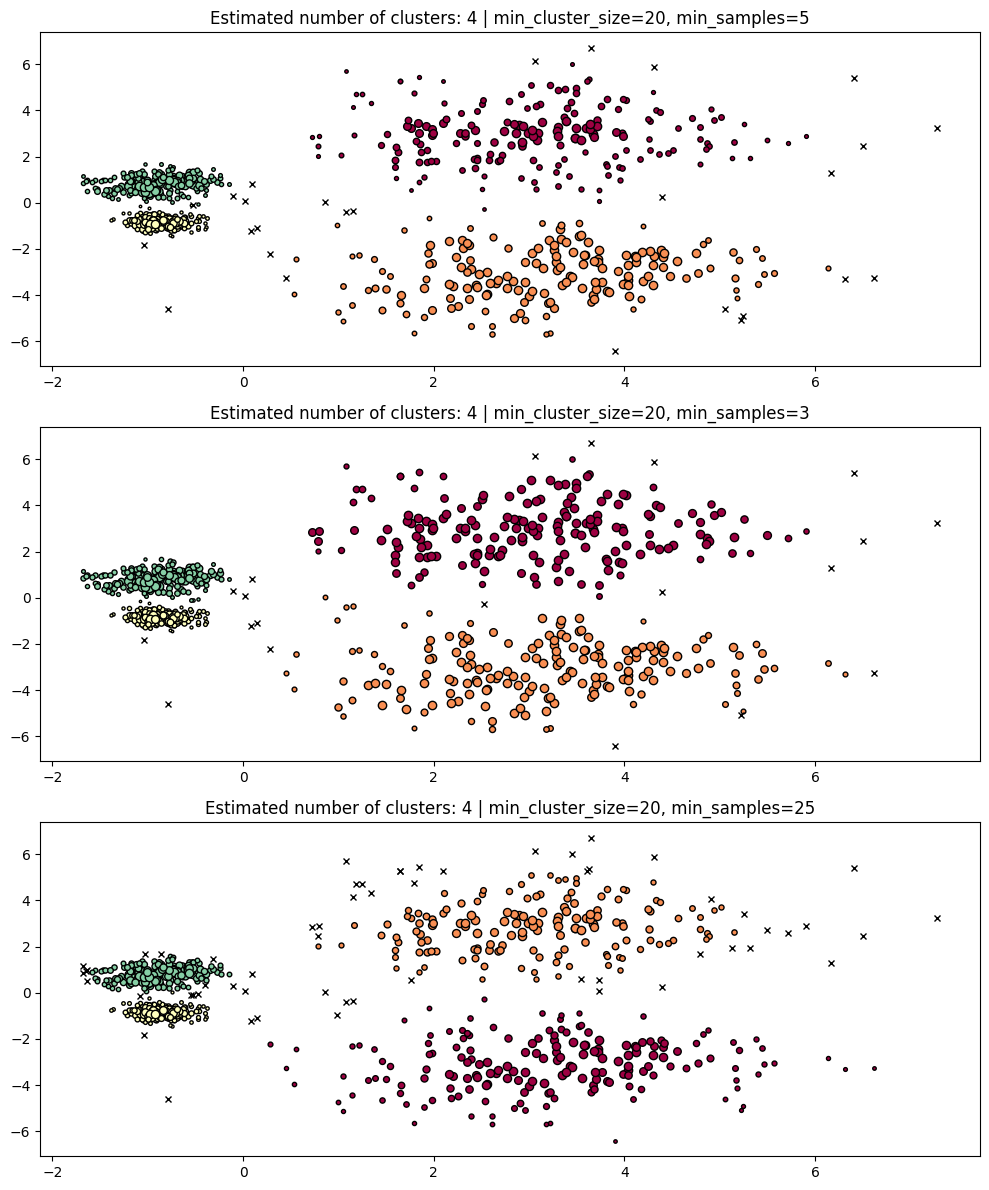

In [ ]:
#Langkah 8: Eksperimen Hyperparameter min_samples
PARAM = (
    {"min_cluster_size": 20, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 3},
    {"min_cluster_size": 20, "min_samples": 25},)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    plot(X, hdb.labels_, hdb.probabilities_, param, ax=axes[i])

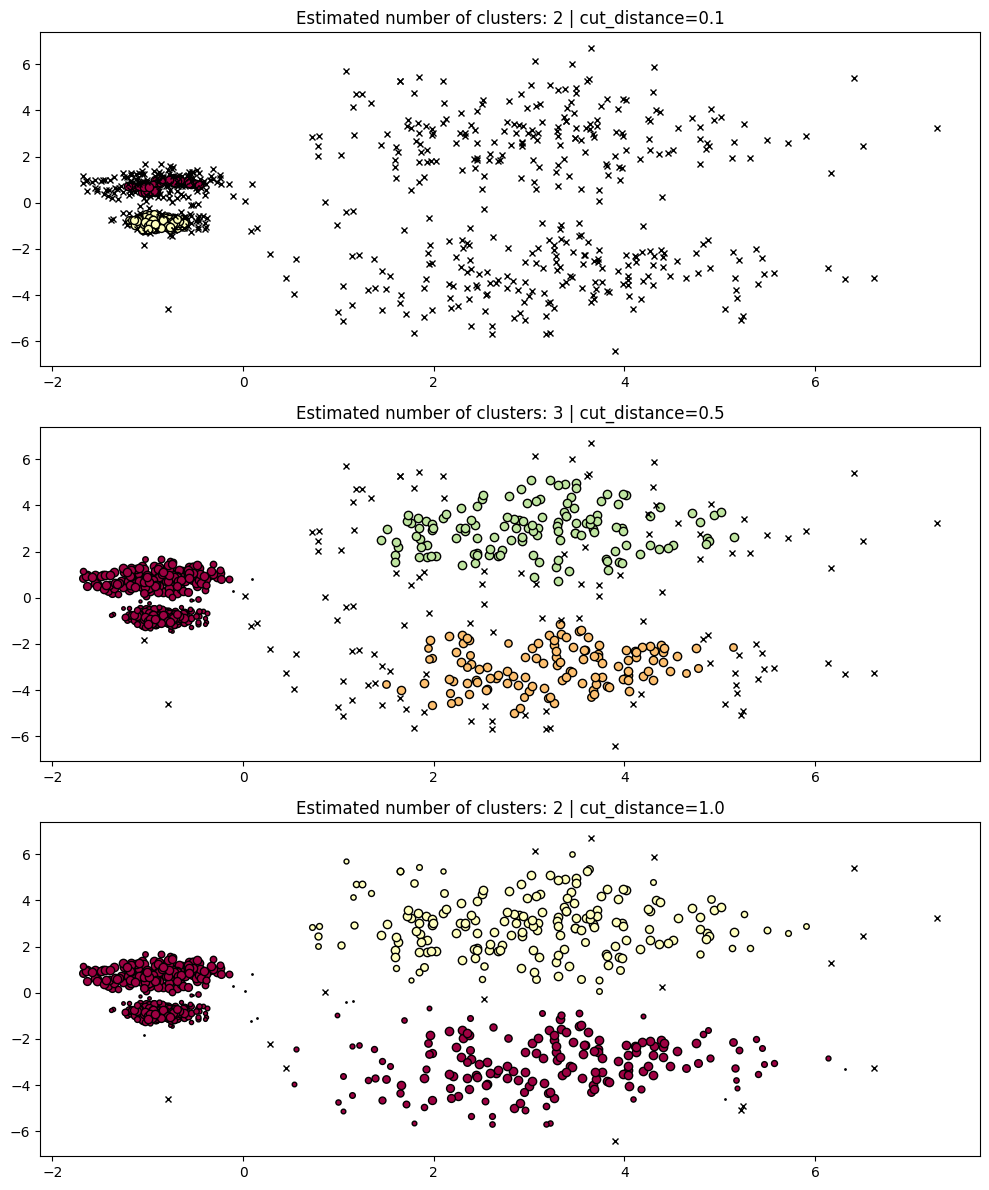

In [ ]:
#Langkah 9: DBSCAN Clustering dari Pohon HDBSCAN
PARAM = (
    {"cut_distance": 0.1},
    {"cut_distance": 0.5},
    {"cut_distance": 1.0},
)
hdb = hdbscan.HDBSCAN().fit(X)
fig, axes = plt.subplots(len(PARAM), 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    labels = hdb.dbscan_clustering(**param)
    plot(X, labels, hdb.probabilities_, param, ax=axes[i])

In [ ]:
#Langkah 10: Evaluasi dengan Silhouette Score
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score untuk hasil clustering HDBSCAN
sil_score = silhouette_score(X, hdb.labels_)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.5743816709862986


In [ ]:
#Langkah 11: Evaluasi dengan Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score

# Menghitung Davies-Bouldin Index untuk hasil clustering HDBSCAN
dbi_score = davies_bouldin_score(X, hdb.labels_)
print(f"Davies-Bouldin Index: {dbi_score}")

Davies-Bouldin Index: 1.6436030674842066


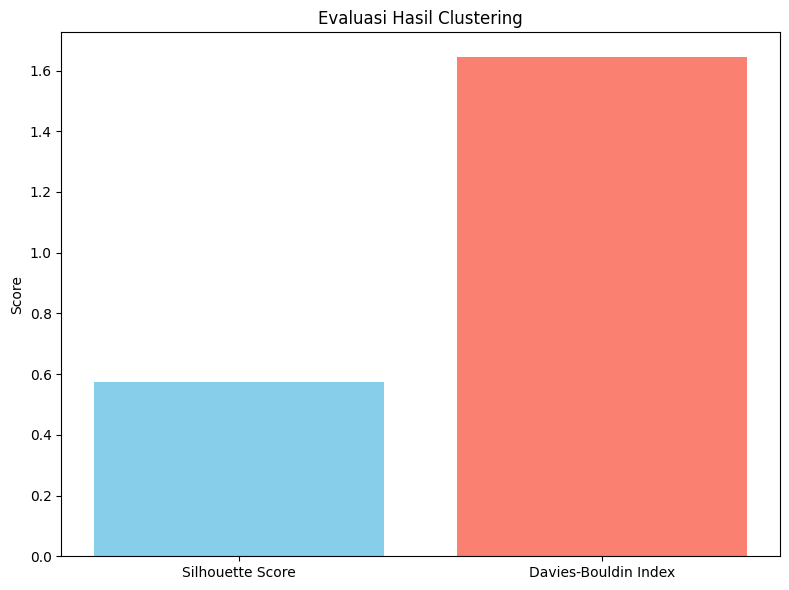

In [ ]:
#Langkah 12: Visualisasi Hasil Evaluasi
# Misalnya kita ingin membandingkan DBI dan Silhouette Score untuk beberapa eksperimen
scores = {"Silhouette Score": sil_score, "Davies-Bouldin Index": dbi_score}

# Plot hasil evaluasi
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(scores.keys(), scores.values(), color=['skyblue', 'salmon'])
ax.set_title("Evaluasi Hasil Clustering")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()



> **Tugas**


1. Pilih salah satu dataset nyata dari sklearn.datasets (misalnya iris dataset atau digits dataset).
2. Lakukan clustering dengan HDBSCAN.
3. Laporkan hasil:
- Jumlah cluster yang terbentuk.
- Banyaknya noise.
- Visualisasi (gunakan PCA/TSNE untuk reduksi dimensi jika perlu).
4. Buat analisis singkat: apakah hasil clustering HDBSCAN sesuai dengan label asli dataset tersebut?


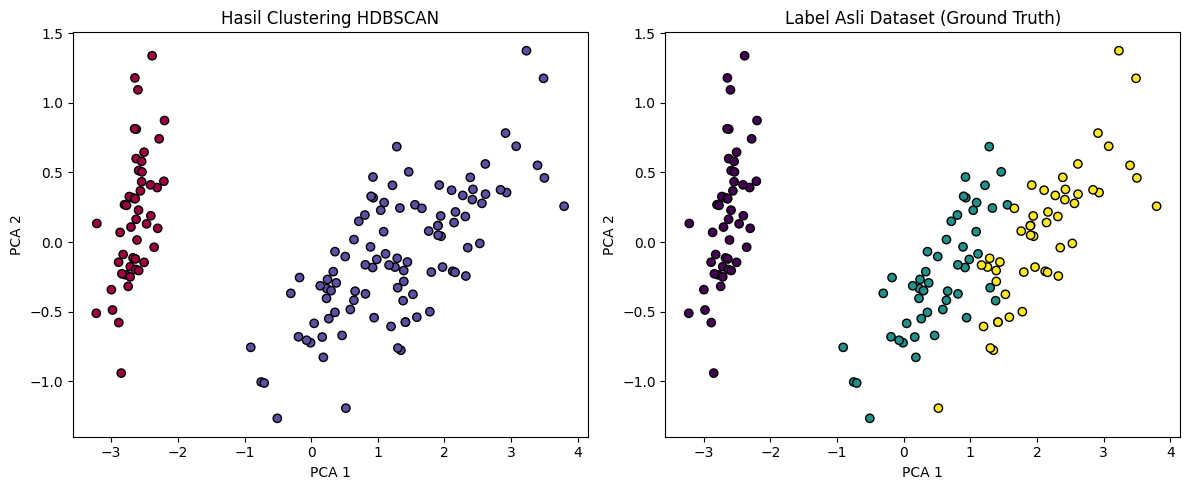

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import hdbscan

# Load dataset
iris = load_iris()
X = iris.data
y_true = iris.target

# Reduksi dimensi ke 2D menggunakan PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Clustering HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=5)
labels = hdb.fit_predict(X)

# Visualisasi
plt.figure(figsize=(12, 5))

# Plot HDBSCAN
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Spectral', edgecolors='k')
plt.title("Hasil Clustering HDBSCAN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Plot Label Asli
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', edgecolors='k')
plt.title("Label Asli Dataset (Ground Truth)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()